<a href="https://colab.research.google.com/github/sayim665/atml-pa1/blob/main/task1/ATML_PA1_Task1_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATML PA1 — Task 1: Inductive Biases and Feature Representations


## Setup
- **Dataset:** STL-10 — 10 classes, 5000 labeled train images, 8000 test images.
- **Backbones:** ResNet-50 (`IMAGENET1K_V2`), ViT-B/16 (`IMAGENET1K_V1`), OpenCLIP ViT-B-32 (`openai`, QuickGELU variant).
- **Seed:** 6304, used for the train/val split, the eval subset, the patch-shuffle permutation, and every other seeded step required by the spec.

This notebook runs the six required experiments in order: clean baseline, color bias, shape-vs-texture
cue conflicts, translation, patch-structure shuffling, and representation-stability analysis. Results
are saved as JSON files after each step so every number reported in the write-up traces back to a
specific run.

## 0. Setup

In [1]:
!pip install -q open_clip_torch timm umap-learn
!pip install -q git+https://github.com/rwightman/pytorch-image-models 2>/dev/null || true


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [36]:
import os, json, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights
import open_clip

SEED = 6304
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

from google.colab import drive
drive.mount('/content/drive')
RESULTS_DIR = "/content/drive/MyDrive/atml_pa1_task1"
os.makedirs(RESULTS_DIR, exist_ok=True)


Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Config

`DATASET` is your Task-1 dataset choice (spec recommends STL-10). Keep this the single source of truth —
every later cell reads from here so switching datasets later doesn't mean re-writing the notebook.


In [3]:
DATASET = "stl10"          # "stl10" or "oxford_pets"
IMG_SIZE = 224
N_TEST_SUBSET = 500         # class-balanced eval subset, seed 6304
BATCH_SIZE = 64
HEAD_EPOCHS = 50
HEAD_LR = 1e-3
HEAD_WD = 1e-4
EARLY_STOP_PATIENCE = 5


## 2. Data: load, stratified 80/20 split (seed 6304), class-balanced 500-image eval subset

In [4]:
# Backbone-agnostic base transform: resize to a common 224x224 RGB canvas.
# Each backbone's OWN normalization is applied separately at feature-extraction time
# (the spec requires interventions to be built on a common image before each model's normalization).
base_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),  # keep in [0,1]; normalization happens per-backbone later
])

if DATASET == "stl10":
    train_full = torchvision.datasets.STL10(root="./data", split="train", download=True, transform=base_transform)
    test_full  = torchvision.datasets.STL10(root="./data", split="test",  download=True, transform=base_transform)
    CLASS_NAMES = train_full.classes
    train_labels = np.array(train_full.labels)
elif DATASET == "oxford_pets":
    train_full = torchvision.datasets.OxfordIIITPet(root="./data", split="trainval", download=True, transform=base_transform)
    test_full  = torchvision.datasets.OxfordIIITPet(root="./data", split="test",     download=True, transform=base_transform)
    CLASS_NAMES = train_full.classes
    train_labels = np.array([train_full._labels[i] for i in range(len(train_full))])
else:
    raise ValueError(DATASET)

print(f"{DATASET}: {len(train_full)} train, {len(test_full)} test, {len(CLASS_NAMES)} classes")


100%|██████████| 2.64G/2.64G [01:26<00:00, 30.5MB/s]


stl10: 5000 train, 8000 test, 10 classes


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# Stratified 80/20 split of the official TRAIN partition, seed 6304
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(train_labels)), train_labels))
train_subset = Subset(train_full, train_idx)
val_subset   = Subset(train_full, val_idx)
print(f"Head-training split: {len(train_subset)} train / {len(val_subset)} val")

# Class-balanced 500-image TEST subset, seed 6304. If a class is short, use all of it and log the shortfall.
def class_balanced_subset(dataset, labels, n_total, seed=SEED, class_names=None):
    rng = np.random.RandomState(seed)
    n_classes = len(class_names) if class_names is not None else len(np.unique(labels))
    per_class = n_total // n_classes
    chosen, shortfall = [], {}
    for c in range(n_classes):
        c_idx = np.where(labels == c)[0]
        rng.shuffle(c_idx)
        take = min(per_class, len(c_idx))
        if take < per_class:
            shortfall[c] = (take, per_class)
        chosen.extend(c_idx[:take].tolist())
    return np.array(chosen), shortfall

if DATASET == "stl10":
    test_labels = np.array(test_full.labels)
else:
    test_labels = np.array([test_full._labels[i] for i in range(len(test_full))])

eval_idx, shortfall = class_balanced_subset(test_full, test_labels, N_TEST_SUBSET, seed=SEED, class_names=CLASS_NAMES)
eval_subset = Subset(test_full, eval_idx)
print(f"Eval subset: {len(eval_subset)} images. Shortfall per class (class_idx: (got, wanted)): {shortfall}")

# Save the exact image identifiers used, as required by the spec.
np.save(os.path.join(RESULTS_DIR, f"eval_idx_{DATASET}.npy"), eval_idx)


Head-training split: 4000 train / 1000 val
Eval subset: 500 images. Shortfall per class (class_idx: (got, wanted)): {}


## 3. Backbones + per-model normalization

Each backbone keeps its own preprocessing normalization, applied AFTER any shared 224x224 intervention.
Heads are trained on **frozen** features (global-avg-pool ResNet feature / ViT class token / normalized CLIP embedding).


In [6]:
resnet_norm = T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
vit_norm    = T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  # matches ViT_B_16_Weights.IMAGENET1K_V1 transforms

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(DEVICE).eval()
resnet_feat_dim = resnet.fc.in_features
resnet.fc = nn.Identity()  # expose the pooled 2048-d feature

vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).to(DEVICE).eval()
vit_feat_dim = vit.heads.head.in_features
vit.heads = nn.Identity()  # expose the [CLS] token feature

clip_model, _, clip_preprocess_val = open_clip.create_model_and_transforms(
    'ViT-B-32-quickgelu', pretrained='openai'
)

clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_norm = T.Normalize(mean=[0.48145466,0.4578275,0.40821073], std=[0.26862954,0.26130258,0.27577711])
clip_feat_dim = clip_model.visual.output_dim

for p in resnet.parameters(): p.requires_grad_(False)
for p in vit.parameters(): p.requires_grad_(False)
for p in clip_model.parameters(): p.requires_grad_(False)

@torch.no_grad()
def extract_features(model_name, images_0_1):
    """images_0_1: (B,3,H,W) float tensor already resized to 224x224, values in [0,1].
    Returns L2-normalized-where-appropriate feature tensor of shape (B, D)."""
    images_0_1 = images_0_1.to(DEVICE)
    if model_name == "resnet":
        x = resnet_norm(images_0_1)
        return resnet(x)
    elif model_name == "vit":
        x = vit_norm(images_0_1)
        return vit(x)
    elif model_name == "clip":
        x = clip_norm(images_0_1)
        feat = clip_model.encode_image(x)
        return F.normalize(feat, dim=-1)
    else:
        raise ValueError(model_name)

FEAT_DIMS = {"resnet": resnet_feat_dim, "vit": vit_feat_dim, "clip": clip_feat_dim}
print(FEAT_DIMS)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 165MB/s]


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

{'resnet': 2048, 'vit': 768, 'clip': 512}


## 4. Linear classifier heads (AdamW, seed 6304, early stopping)

In [7]:
@torch.no_grad()
def featurize_loader(model_name, loader):
    feats, labels = [], []
    for imgs, ys in loader:
        f = extract_features(model_name, imgs)
        feats.append(f.cpu()); labels.append(ys)
    return torch.cat(feats), torch.cat(labels)

def train_linear_head(model_name, n_classes, train_loader, val_loader):
    set_seed(SEED)
    head = nn.Linear(FEAT_DIMS[model_name], n_classes).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=HEAD_LR, weight_decay=HEAD_WD)

    # Pre-extract features once (frozen backbone) — much faster than re-extracting every epoch.
    Xtr, ytr = featurize_loader(model_name, train_loader)
    Xval, yval = featurize_loader(model_name, val_loader)
    Xtr, ytr, Xval, yval = Xtr.to(DEVICE), ytr.to(DEVICE), Xval.to(DEVICE), yval.to(DEVICE)

    best_acc, best_state, patience = -1, None, 0
    for epoch in range(HEAD_EPOCHS):
        head.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            opt.zero_grad()
            loss = F.cross_entropy(head(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step()

        head.eval()
        with torch.no_grad():
            val_acc = (head(Xval).argmax(-1) == yval).float().mean().item()
        if val_acc > best_acc:
            best_acc, best_state, patience = val_acc, {k: v.clone() for k, v in head.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= EARLY_STOP_PATIENCE:
                break
    head.load_state_dict(best_state)
    print(f"[{model_name}] best val acc = {best_acc:.4f} (epoch {epoch+1})")
    return head

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

heads = {}
for name in ["resnet", "vit", "clip"]:
    heads[name] = train_linear_head(name, len(CLASS_NAMES), train_loader, val_loader)


[resnet] best val acc = 0.9730 (epoch 11)
[vit] best val acc = 0.9810 (epoch 10)
[clip] best val acc = 0.9860 (epoch 21)


## 5. Zero-shot CLIP (fixed prompt: `a photo of a {class}.`)

In [8]:
@torch.no_grad()
def clip_zeroshot_logits(images_0_1, class_names=CLASS_NAMES):
    prompts = [f"a photo of a {c}." for c in class_names]
    text_tokens = clip_tokenizer(prompts).to(DEVICE)
    text_feat = F.normalize(clip_model.encode_text(text_tokens), dim=-1)
    img_feat = extract_features("clip", images_0_1)  # already normalized
    logit_scale = clip_model.logit_scale.exp()
    return logit_scale * img_feat @ text_feat.t()


## 6. Step 1 — Clean baseline

Report top-1 accuracy, macro-F1, mean max confidence for all three heads + zero-shot CLIP,
on the fixed 500-image eval subset.


In [9]:
from sklearn.metrics import f1_score

eval_loader = DataLoader(eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

@torch.no_grad()
def evaluate_head(model_name, head, loader):
    all_preds, all_labels, all_conf = [], [], []
    for imgs, ys in loader:
        feats = extract_features(model_name, imgs)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1)
        conf, pred = probs.max(-1)
        all_preds.append(pred.cpu()); all_labels.append(ys); all_conf.append(conf.cpu())
    preds = torch.cat(all_preds).numpy(); labels = torch.cat(all_labels).numpy(); conf = torch.cat(all_conf).numpy()
    acc = (preds == labels).mean()
    f1 = f1_score(labels, preds, average="macro")
    return {"acc": float(acc), "macro_f1": float(f1), "mean_conf": float(conf.mean())}

@torch.no_grad()
def evaluate_clip_zeroshot(loader):
    all_preds, all_labels, all_conf = [], [], []
    for imgs, ys in loader:
        logits = clip_zeroshot_logits(imgs)
        probs = F.softmax(logits, dim=-1)
        conf, pred = probs.max(-1)
        all_preds.append(pred.cpu()); all_labels.append(ys); all_conf.append(conf.cpu())
    preds = torch.cat(all_preds).numpy(); labels = torch.cat(all_labels).numpy(); conf = torch.cat(all_conf).numpy()
    acc = (preds == labels).mean()
    f1 = f1_score(labels, preds, average="macro")
    return {"acc": float(acc), "macro_f1": float(f1), "mean_conf": float(conf.mean())}

clean_results = {}
for name in ["resnet", "vit", "clip"]:
    clean_results[name] = evaluate_head(name, heads[name], eval_loader)
clean_results["clip_zeroshot"] = evaluate_clip_zeroshot(eval_loader)

print(json.dumps(clean_results, indent=2))
with open(os.path.join(RESULTS_DIR, "step1_clean_baseline.json"), "w") as f:
    json.dump(clean_results, f, indent=2)


{
  "resnet": {
    "acc": 0.968,
    "macro_f1": 0.9679823740993083,
    "mean_conf": 0.9310794472694397
  },
  "vit": {
    "acc": 0.962,
    "macro_f1": 0.962268942558666,
    "mean_conf": 0.9518065452575684
  },
  "clip": {
    "acc": 0.972,
    "macro_f1": 0.9720137501974353,
    "mean_conf": 0.74178546667099
  },
  "clip_zeroshot": {
    "acc": 0.964,
    "macro_f1": 0.9639862389675955,
    "mean_conf": 0.9360694289207458
  }
}


## 7. Step 2 — Color bias (grayscale + your chosen extra transform)

Grayscale is fixed. Pick ONE of {fixed hue rotation, palette transfer, class-swapped color statistics} below —
this is one of your required experimental-design choices. State your hypothesis before you look at the numbers.


In [10]:
def to_grayscale_3ch(imgs):
    gray = T.functional.rgb_to_grayscale(imgs, num_output_channels=3)
    return gray

# TODO (experimental-design choice): implement ONE of hue-rotation / palette-transfer / class-swapped stats.
# Starter for hue rotation (simplest to implement correctly):
def hue_rotate(imgs, degrees=90):
    # torchvision's ColorJitter hue expects a factor in [-0.5, 0.5] mapped to [-180, 180] degrees
    hue_factor = (degrees % 360) / 360.0
    if hue_factor > 0.5: hue_factor -= 1.0
    return torch.stack([T.functional.adjust_hue(img, hue_factor) for img in imgs])

def apply_color_intervention(imgs, kind="grayscale"):
    if kind == "grayscale":
        return to_grayscale_3ch(imgs)
    elif kind == "hue_rotate":
        return hue_rotate(imgs, degrees=90)   # TODO: justify your chosen degree in the report
    else:
        raise NotImplementedError("Implement palette_transfer / class_swap if you choose those instead")

@torch.no_grad()
def evaluate_under_transform(model_name, head, loader, transform_fn, is_clip_zeroshot=False):
    all_preds, all_labels, clean_preds = [], [], []
    for imgs, ys in loader:
        t_imgs = transform_fn(imgs)
        if is_clip_zeroshot:
            logits = clip_zeroshot_logits(t_imgs)
        else:
            feats = extract_features(model_name, t_imgs)
            logits = head(feats)
        preds = logits.argmax(-1).cpu()
        all_preds.append(preds); all_labels.append(ys)
    preds = torch.cat(all_preds).numpy(); labels = torch.cat(all_labels).numpy()
    acc = (preds == labels).mean()
    return acc, preds

# Compute clean predictions once per model (needed for "prediction consistency relative to clean")
@torch.no_grad()
def get_clean_preds(model_name, head, loader, is_clip_zeroshot=False):
    all_preds = []
    for imgs, ys in loader:
        if is_clip_zeroshot:
            logits = clip_zeroshot_logits(imgs)
        else:
            feats = extract_features(model_name, imgs)
            logits = head(feats)
        all_preds.append(logits.argmax(-1).cpu())
    return torch.cat(all_preds).numpy()

color_results = {}
for name in ["resnet", "vit", "clip"]:
    clean_preds = get_clean_preds(name, heads[name], eval_loader)
    for kind in ["grayscale", "hue_rotate"]:
        acc, preds = evaluate_under_transform(name, heads[name], eval_loader, lambda x, k=kind: apply_color_intervention(x, k))
        consistency = (preds == clean_preds).mean()
        color_results[f"{name}_{kind}"] = {"acc": float(acc), "consistency_vs_clean": float(consistency)}

print(json.dumps(color_results, indent=2))
with open(os.path.join(RESULTS_DIR, "step2_color_bias.json"), "w") as f:
    json.dump(color_results, f, indent=2)


{
  "resnet_grayscale": {
    "acc": 0.946,
    "consistency_vs_clean": 0.956
  },
  "resnet_hue_rotate": {
    "acc": 0.946,
    "consistency_vs_clean": 0.952
  },
  "vit_grayscale": {
    "acc": 0.944,
    "consistency_vs_clean": 0.958
  },
  "vit_hue_rotate": {
    "acc": 0.93,
    "consistency_vs_clean": 0.95
  },
  "clip_grayscale": {
    "acc": 0.936,
    "consistency_vs_clean": 0.942
  },
  "clip_hue_rotate": {
    "acc": 0.934,
    "consistency_vs_clean": 0.94
  }
}


## 8. Step 3 — Shape vs. texture (cue-conflict via AdaIN)

This is the most experimental-design-heavy step. You need:
1. A style-transfer implementation (AdaIN is suggested — several public PyTorch implementations exist; check
   the README attribution requirement if you use one).
2. At least 5 unordered class pairs, both directions where feasible, ≥200 valid conflicts.
3. A **visual rejection rule defined BEFORE looking at model predictions** (e.g., reject stylizations where
   the content structure is destroyed beyond recognition — define a concrete, reproducible criterion).

Below is scaffolding for the *evaluation* side once you have a folder of generated cue-conflict images with
known (shape_label, texture_label) pairs — plug in your AdaIN generation separately (it's its own script,
see the suggested `data/make_cue_conflicts.py` in the assignment's repo layout).


In [11]:
# TODO: point this at your generated cue-conflict images.
# Expected format: a list of dicts {"path": ..., "shape_label": int, "texture_label": int}
CUE_CONFLICT_MANIFEST = os.path.join(RESULTS_DIR, "cue_conflicts_manifest.json")

def classify_prediction(pred, shape_label, texture_label):
    if pred == shape_label: return "shape"
    elif pred == texture_label: return "texture"
    else: return "other"

def compute_shape_bias(records):
    # records: list of {"pred": int, "shape_label": int, "texture_label": int}
    n_shape = sum(1 for r in records if classify_prediction(r["pred"], r["shape_label"], r["texture_label"]) == "shape")
    n_texture = sum(1 for r in records if classify_prediction(r["pred"], r["shape_label"], r["texture_label"]) == "texture")
    n_total = len(records)
    shape_bias = 100 * n_shape / max(1, (n_shape + n_texture))
    coverage = 100 * (n_shape + n_texture) / max(1, n_total)
    return {"shape_bias_pct": shape_bias, "coverage_pct": coverage, "n_shape": n_shape, "n_texture": n_texture, "n_total": n_total}

# Once CUE_CONFLICT_MANIFEST exists, run each model over it and call compute_shape_bias per model.
# This part is intentionally left for you to wire up after generating the conflicts — the pipeline is
# identical in shape to Steps 6-7 above (extract_features -> head -> argmax -> compare to labels).
print("Fill in cue-conflict generation, then reuse evaluate_under_transform-style logic here.")


Fill in cue-conflict generation, then reuse evaluate_under_transform-style logic here.


In [20]:
import subprocess, sys

ADAIN_DIR = "/content/pytorch-AdaIN"
if not os.path.exists(ADAIN_DIR):
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/naoto0804/pytorch-AdaIN.git", ADAIN_DIR], check=True)

os.makedirs(f"{ADAIN_DIR}/models", exist_ok=True)

# decoder.pth is already confirmed working from your last run.
decoder_path = f"{ADAIN_DIR}/models/decoder.pth"
if not os.path.exists(decoder_path):
    subprocess.run(["wget", "-q", "-O", decoder_path,
                     "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"], check=True)
print("decoder.pth ready")

# vgg weights: try both spellings, since the release asset name doesn't match the README text.
vgg_path = f"{ADAIN_DIR}/models/vgg_normalized.pth"
if not os.path.exists(vgg_path):
    for candidate in ["vgg_normalised.pth", "vgg_normalized.pth"]:
        url = f"https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/{candidate}"
        result = subprocess.run(["wget", "-q", "-O", vgg_path, url])
        if result.returncode == 0 and os.path.getsize(vgg_path) > 1_000_000:  # sanity check it's not an error page
            print(f"Downloaded vgg weights as '{candidate}'")
            break
    else:
        raise RuntimeError("Could not download vgg weights under either spelling.")
else:
    print("vgg_normalized.pth already present")

sys.path.insert(0, ADAIN_DIR)
import net as adain_net
import function as adain_function

decoder.pth ready
Downloaded vgg weights as 'vgg_normalised.pth'


In [21]:
adain_decoder = adain_net.decoder
adain_vgg = adain_net.vgg

adain_decoder.eval()
adain_vgg.eval()
adain_decoder.load_state_dict(torch.load(f"{ADAIN_DIR}/models/decoder.pth", map_location=DEVICE))
adain_vgg.load_state_dict(torch.load(f"{ADAIN_DIR}/models/vgg_normalized.pth", map_location=DEVICE))
adain_vgg = torch.nn.Sequential(*list(adain_vgg.children())[:31])

adain_vgg.to(DEVICE)
adain_decoder.to(DEVICE)
for p in adain_vgg.parameters(): p.requires_grad_(False)
for p in adain_decoder.parameters(): p.requires_grad_(False)

@torch.no_grad()
def adain_stylize(content_0_1, style_0_1, alpha=1.0):
    content_f = adain_vgg(content_0_1.to(DEVICE))
    style_f = adain_vgg(style_0_1.to(DEVICE))
    feat = adain_function.adaptive_instance_normalization(content_f, style_f)
    feat = alpha * feat + (1 - alpha) * content_f
    out = adain_decoder(feat)
    return out.clamp(0, 1).cpu()

print("AdaIN ready.")

AdaIN ready.


In [22]:
import cv2
from itertools import product

CLASS_PAIRS = [
    ("cat", "dog"),
    ("horse", "deer"),
    ("car", "truck"),
    ("bird", "airplane"),
    ("monkey", "dog"),
]
N_TARGET_CONFLICTS = 220
ALPHA = 1.0
EDGE_RETENTION_THRESHOLD = 0.30

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
for a, b in CLASS_PAIRS:
    assert a in class_to_idx and b in class_to_idx, f"{a} or {b} not in {CLASS_NAMES}"

def indices_for_class(dataset_labels, class_idx):
    return np.where(dataset_labels == class_idx)[0]

def edge_retention_ratio(content_img_0_1, stylized_img_0_1):
    def edges(img_t):
        img_np = (img_t.squeeze(0).permute(1,2,0).numpy() * 255).astype(np.uint8)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        return cv2.Canny(gray, 100, 200)
    c_edges = edges(content_img_0_1)
    s_edges = edges(stylized_img_0_1)
    c_count = (c_edges > 0).sum()
    if c_count == 0:
        return 1.0
    kernel = np.ones((3,3), np.uint8)
    c_dilated = cv2.dilate(c_edges, kernel, iterations=1)
    overlap = np.logical_and(s_edges > 0, c_dilated > 0).sum()
    return overlap / c_count

print("Rejection rule + class pairs configured.")

Rejection rule + class pairs configured.


In [24]:
set_seed(SEED)
rng2 = np.random.RandomState(SEED)

manifest = []
accepted, rejected = 0, 0
os.makedirs(os.path.join(RESULTS_DIR, "cue_conflicts"), exist_ok=True)

directed_pairs = []
for a, b in CLASS_PAIRS:
    directed_pairs.append((a, b))
    directed_pairs.append((b, a))

per_direction_target = math.ceil(N_TARGET_CONFLICTS / len(directed_pairs))

to_pil = T.ToPILImage()

for shape_class, texture_class in directed_pairs:
    shape_idx = class_to_idx[shape_class]
    texture_idx = class_to_idx[texture_class]
    shape_pool = indices_for_class(train_labels, shape_idx)
    texture_pool = indices_for_class(train_labels, texture_idx)
    rng2.shuffle(shape_pool); rng2.shuffle(texture_pool)

    made_this_direction = 0
    attempt = 0
    while made_this_direction < per_direction_target and attempt < per_direction_target * 4:
        c_idx = shape_pool[attempt % len(shape_pool)]
        s_idx = texture_pool[attempt % len(texture_pool)]
        attempt += 1

        content_img, _ = train_full[c_idx]
        style_img, _ = train_full[s_idx]
        content_batch = content_img.unsqueeze(0)
        style_batch = style_img.unsqueeze(0)

        stylized = adain_stylize(content_batch, style_batch, alpha=ALPHA)
        ratio = edge_retention_ratio(content_batch, stylized)

        if ratio >= EDGE_RETENTION_THRESHOLD:
            fname = f"{shape_class}_shape__{texture_class}_texture__{accepted:04d}.png"
            content_fname = f"{shape_class}_shape__{texture_class}_texture__{accepted:04d}_content.png"
            fpath = os.path.join(RESULTS_DIR, "cue_conflicts", fname)
            content_fpath = os.path.join(RESULTS_DIR, "cue_conflicts", content_fname)
            to_pil(stylized.squeeze(0)).save(fpath)
            to_pil(content_batch.squeeze(0)).save(content_fpath)
            manifest.append({
                "path": fpath,
                "content_path": content_fpath,
                "shape_label": int(shape_idx),
                "texture_label": int(texture_idx),
                "shape_class": shape_class,
                "texture_class": texture_class,
                "edge_retention_ratio": float(ratio),
            })
            accepted += 1
            made_this_direction += 1
        else:
            rejected += 1

    print(f"{shape_class} (shape) / {texture_class} (texture): {made_this_direction} accepted")

print(f"\nTotal accepted: {accepted}, rejected: {rejected} (target was >= {N_TARGET_CONFLICTS})")

with open(CUE_CONFLICT_MANIFEST, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"Manifest saved: {CUE_CONFLICT_MANIFEST}")

cat (shape) / dog (texture): 22 accepted
dog (shape) / cat (texture): 22 accepted
horse (shape) / deer (texture): 22 accepted
deer (shape) / horse (texture): 22 accepted
car (shape) / truck (texture): 22 accepted
truck (shape) / car (texture): 22 accepted
bird (shape) / airplane (texture): 22 accepted
airplane (shape) / bird (texture): 22 accepted
monkey (shape) / dog (texture): 22 accepted
dog (shape) / monkey (texture): 22 accepted

Total accepted: 220, rejected: 31 (target was >= 220)
Manifest saved: /content/drive/MyDrive/atml_pa1_task1/cue_conflicts_manifest.json


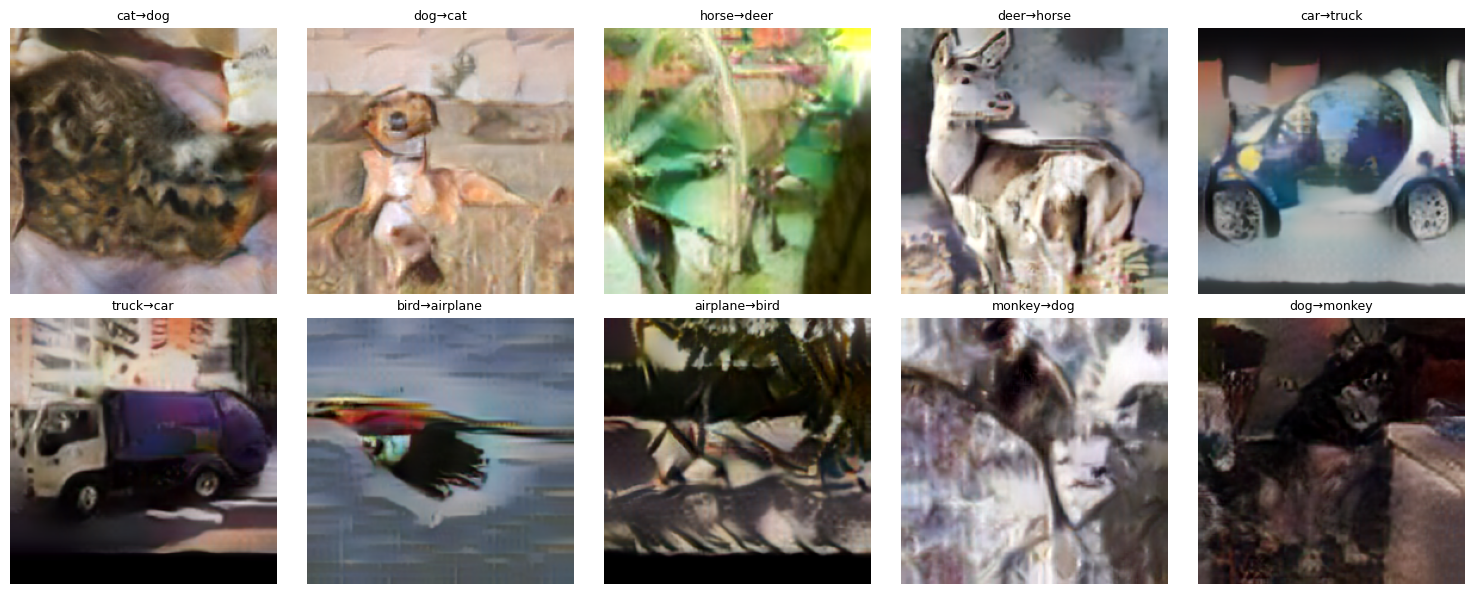

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, rec in enumerate(manifest[::22][:10]):  # one example from each direction
    axes.flat[i].imshow(Image.open(rec["path"]))
    axes.flat[i].set_title(f'{rec["shape_class"]}→{rec["texture_class"]}', fontsize=9)
    axes.flat[i].axis("off")
plt.tight_layout()
plt.show()

In [26]:
from PIL import Image

def load_manifest_as_tensor_batch(records, batch_size=BATCH_SIZE):
    for i in range(0, len(records), batch_size):
        chunk = records[i:i+batch_size]
        imgs = torch.stack([base_transform(Image.open(r["path"]).convert("RGB")) for r in chunk])
        yield imgs, chunk

@torch.no_grad()
def evaluate_cue_conflicts(model_name, head, manifest_records, is_clip_zeroshot=False):
    records_out = []
    for imgs, chunk in load_manifest_as_tensor_batch(manifest_records):
        if is_clip_zeroshot:
            logits = clip_zeroshot_logits(imgs)
        else:
            feats = extract_features(model_name, imgs)
            logits = head(feats)
        preds = logits.argmax(-1).cpu().numpy()
        for r, p in zip(chunk, preds):
            records_out.append({"pred": int(p), "shape_label": r["shape_label"], "texture_label": r["texture_label"]})
    return records_out

with open(CUE_CONFLICT_MANIFEST) as f:
    manifest = json.load(f)

shape_bias_results = {}
for name in ["resnet", "vit", "clip"]:
    recs = evaluate_cue_conflicts(name, heads[name], manifest)
    shape_bias_results[name] = compute_shape_bias(recs)

recs_zs = evaluate_cue_conflicts("clip", None, manifest, is_clip_zeroshot=True)
shape_bias_results["clip_zeroshot"] = compute_shape_bias(recs_zs)

print(json.dumps(shape_bias_results, indent=2))
with open(os.path.join(RESULTS_DIR, "step3_shape_bias.json"), "w") as f:
    json.dump(shape_bias_results, f, indent=2)

{
  "resnet": {
    "shape_bias_pct": 68.15286624203821,
    "coverage_pct": 71.36363636363636,
    "n_shape": 107,
    "n_texture": 50,
    "n_total": 220
  },
  "vit": {
    "shape_bias_pct": 85.4054054054054,
    "coverage_pct": 84.0909090909091,
    "n_shape": 158,
    "n_texture": 27,
    "n_total": 220
  },
  "clip": {
    "shape_bias_pct": 86.17021276595744,
    "coverage_pct": 85.45454545454545,
    "n_shape": 162,
    "n_texture": 26,
    "n_total": 220
  },
  "clip_zeroshot": {
    "shape_bias_pct": 81.48148148148148,
    "coverage_pct": 85.9090909090909,
    "n_shape": 154,
    "n_texture": 35,
    "n_total": 220
  }
}


## 9. Step 4 — Translation

In [12]:
def translate_reflect(imgs, dx, dy):
    # reflection pad then crop back to original size, shifting by (dx, dy) pixels
    pad = max(abs(dx), abs(dy))
    padded = F.pad(imgs, (pad, pad, pad, pad), mode="reflect")
    H, W = imgs.shape[-2:]
    top = pad - dy
    left = pad - dx
    return padded[..., top:top+H, left:left+W]

DIRECTIONS = [(1,0), (-1,0), (0,1), (0,-1)]  # right, left, down, up (unit vectors)
DISPLACEMENTS = [0, 8, 16, 32]

translation_results = {}
for name in ["resnet", "vit", "clip"]:
    clean_preds = get_clean_preds(name, heads[name], eval_loader)
    per_delta = {}
    for delta in DISPLACEMENTS:
        accs, consist = [], []
        for (ux, uy) in DIRECTIONS:
            dx, dy = ux*delta, uy*delta
            acc, preds = evaluate_under_transform(name, heads[name], eval_loader, lambda x, dx=dx, dy=dy: translate_reflect(x, dx, dy))
            accs.append(acc); consist.append((preds == clean_preds).mean())
            if delta == 0:
                break  # 0-displacement is direction-independent
        per_delta[delta] = {"acc": float(np.mean(accs)), "consistency": float(np.mean(consist))}
    translation_results[name] = per_delta

print(json.dumps(translation_results, indent=2))
with open(os.path.join(RESULTS_DIR, "step4_translation.json"), "w") as f:
    json.dump(translation_results, f, indent=2)

# TODO: plot acc / consistency vs displacement per model (matplotlib line plot, one figure for the report).


{
  "resnet": {
    "0": {
      "acc": 0.968,
      "consistency": 1.0
    },
    "8": {
      "acc": 0.9625,
      "consistency": 0.988
    },
    "16": {
      "acc": 0.9604999999999999,
      "consistency": 0.9864999999999999
    },
    "32": {
      "acc": 0.9570000000000001,
      "consistency": 0.979
    }
  },
  "vit": {
    "0": {
      "acc": 0.962,
      "consistency": 1.0
    },
    "8": {
      "acc": 0.966,
      "consistency": 0.9795
    },
    "16": {
      "acc": 0.9595,
      "consistency": 0.992
    },
    "32": {
      "acc": 0.9555,
      "consistency": 0.9855
    }
  },
  "clip": {
    "0": {
      "acc": 0.972,
      "consistency": 1.0
    },
    "8": {
      "acc": 0.97,
      "consistency": 0.9784999999999999
    },
    "16": {
      "acc": 0.966,
      "consistency": 0.97
    },
    "32": {
      "acc": 0.9615,
      "consistency": 0.9729999999999999
    }
  }
}


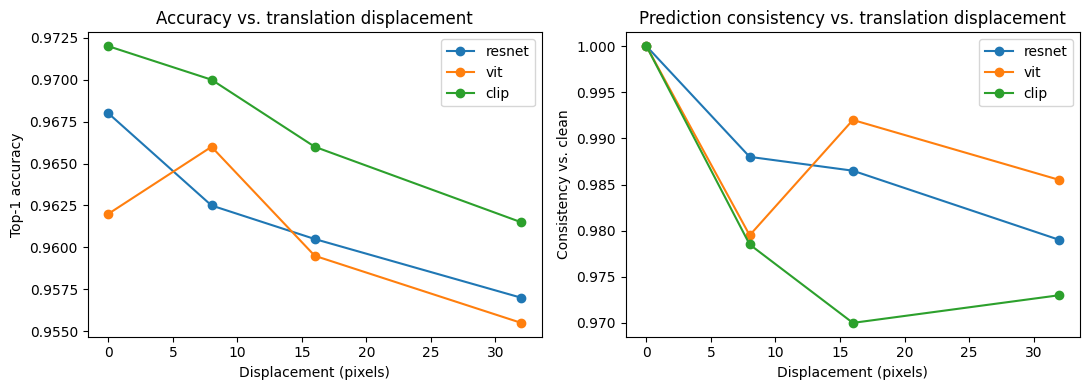

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name in ["resnet", "vit", "clip"]:
    deltas = sorted(translation_results[name].keys())
    accs = [translation_results[name][d]["acc"] for d in deltas]
    cons = [translation_results[name][d]["consistency"] for d in deltas]
    axes[0].plot(deltas, accs, marker="o", label=name)
    axes[1].plot(deltas, cons, marker="o", label=name)

axes[0].set_title("Accuracy vs. translation displacement")
axes[0].set_xlabel("Displacement (pixels)"); axes[0].set_ylabel("Top-1 accuracy")
axes[0].legend()

axes[1].set_title("Prediction consistency vs. translation displacement")
axes[1].set_xlabel("Displacement (pixels)"); axes[1].set_ylabel("Consistency vs. clean")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "step4_translation_plot.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Step 5 — Patch structure (4x4 grid shuffle, seed 6304, one fixed permutation reused across models)

In [15]:
rng = np.random.RandomState(SEED)
GRID = 4
# Fix ONE permutation of the 16 patches, reused for every image and every model.
fixed_perm = rng.permutation(GRID*GRID)
while (fixed_perm == np.arange(GRID*GRID)).all():  # ensure non-identity
    fixed_perm = rng.permutation(GRID*GRID)
print("Patch permutation:", fixed_perm)

def patch_shuffle(imgs, perm=fixed_perm, grid=GRID):
    B, C, H, W = imgs.shape
    ph, pw = H // grid, W // grid
    patches = imgs.unfold(2, ph, ph).unfold(3, pw, pw)  # B,C,grid,grid,ph,pw
    patches = patches.contiguous().view(B, C, grid*grid, ph, pw)
    shuffled = patches[:, :, perm, :, :]
    shuffled = shuffled.view(B, C, grid, grid, ph, pw).permute(0,1,2,4,3,5).contiguous()
    return shuffled.view(B, C, H, W)

patch_results = {}
for name in ["resnet", "vit", "clip"]:
    clean_preds = get_clean_preds(name, heads[name], eval_loader)
    acc, preds = evaluate_under_transform(name, heads[name], eval_loader, patch_shuffle)
    consistency = (preds == clean_preds).mean()
    patch_results[name] = {"acc": float(acc), "consistency_vs_clean": float(consistency)}

print(json.dumps(patch_results, indent=2))
with open(os.path.join(RESULTS_DIR, "step5_patch_shuffle.json"), "w") as f:
    json.dump(patch_results, f, indent=2)


Patch permutation: [ 9  4  8  1 13  0  3 15  6 12 14  7 11 10  5  2]
{
  "resnet": {
    "acc": 0.89,
    "consistency_vs_clean": 0.908
  },
  "vit": {
    "acc": 0.882,
    "consistency_vs_clean": 0.908
  },
  "clip": {
    "acc": 0.844,
    "consistency_vs_clean": 0.852
  }
}


## 11. Step 6 — Representation analysis (cosine stability + t-SNE/UMAP)

For grayscale, cue-conflict, translation, and patch-shuffling: pair each transformed image with its clean
counterpart and compute mean cosine similarity between their frozen representations. Then fit one 2D
projection per backbone over the combined clean+transformed features.


In [27]:
@torch.no_grad()
def mean_cosine_stability(model_name, loader, transform_fn):
    sims = []
    for imgs, ys in loader:
        clean_f = extract_features(model_name, imgs)
        t_f = extract_features(model_name, transform_fn(imgs))
        cos = F.cosine_similarity(clean_f, t_f, dim=-1)
        sims.append(cos.cpu())
    return torch.cat(sims).mean().item()

rep_stability = {}
transforms_to_test = {
    "grayscale": lambda x: apply_color_intervention(x, "grayscale"),
    "translation_16px_right": lambda x: translate_reflect(x, 16, 0),
    "patch_shuffle": patch_shuffle,
    # "cue_conflict": ...  # TODO once Step 3 images are ready, load pairs and compute similarly
}
for name in ["resnet", "vit", "clip"]:
    rep_stability[name] = {}
    for t_name, t_fn in transforms_to_test.items():
        rep_stability[name][t_name] = mean_cosine_stability(name, eval_loader, t_fn)

print(json.dumps(rep_stability, indent=2))
with open(os.path.join(RESULTS_DIR, "step6_representation_stability.json"), "w") as f:
    json.dump(rep_stability, f, indent=2)


{
  "resnet": {
    "grayscale": 0.798108696937561,
    "translation_16px_right": 0.9442152380943298,
    "patch_shuffle": 0.6982101798057556
  },
  "vit": {
    "grayscale": 0.7312588095664978,
    "translation_16px_right": 0.9711867570877075,
    "patch_shuffle": 0.5895035266876221
  },
  "clip": {
    "grayscale": 0.8876953125,
    "translation_16px_right": 0.9619584679603577,
    "patch_shuffle": 0.7377856969833374
  }
}


In [28]:
@torch.no_grad()
def cue_conflict_cosine_stability(model_name, manifest_records, batch_size=BATCH_SIZE):
    sims = []
    for i in range(0, len(manifest_records), batch_size):
        chunk = manifest_records[i:i+batch_size]
        stylized_imgs = torch.stack([base_transform(Image.open(r["path"]).convert("RGB")) for r in chunk])
        content_imgs = torch.stack([base_transform(Image.open(r["content_path"]).convert("RGB")) for r in chunk])
        clean_f = extract_features(model_name, content_imgs)
        stylized_f = extract_features(model_name, stylized_imgs)
        cos = F.cosine_similarity(clean_f, stylized_f, dim=-1)
        sims.append(cos.cpu())
    return torch.cat(sims).mean().item()

for name in ["resnet", "vit", "clip"]:
    rep_stability[name]["cue_conflict"] = cue_conflict_cosine_stability(name, manifest)

print(json.dumps(rep_stability, indent=2))
with open(os.path.join(RESULTS_DIR, "step6_representation_stability.json"), "w") as f:
    json.dump(rep_stability, f, indent=2)

{
  "resnet": {
    "grayscale": 0.798108696937561,
    "translation_16px_right": 0.9442152380943298,
    "patch_shuffle": 0.6982101798057556,
    "cue_conflict": 0.38098499178886414
  },
  "vit": {
    "grayscale": 0.7312588095664978,
    "translation_16px_right": 0.9711867570877075,
    "patch_shuffle": 0.5895035266876221,
    "cue_conflict": 0.3959818184375763
  },
  "clip": {
    "grayscale": 0.8876953125,
    "translation_16px_right": 0.9619584679603577,
    "patch_shuffle": 0.7377856969833374,
    "cue_conflict": 0.7493575811386108
  }
}


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


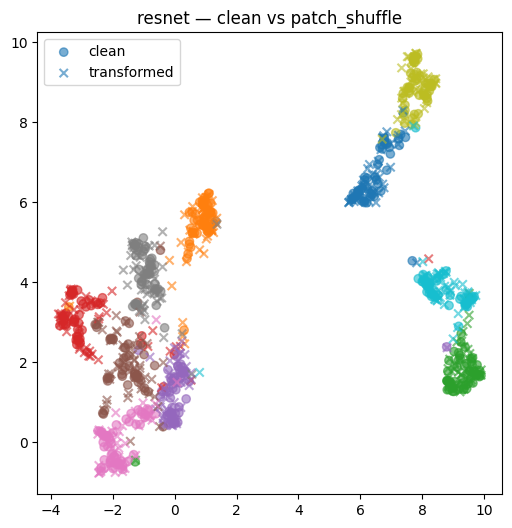

In [30]:
import umap  # or: from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_clean_and_transformed(model_name, loader, transform_fn):
    clean_feats, trans_feats, labels = [], [], []
    for imgs, ys in loader:
        clean_feats.append(extract_features(model_name, imgs).cpu())
        trans_feats.append(extract_features(model_name, transform_fn(imgs)).cpu())
        labels.append(ys)
    return torch.cat(clean_feats).numpy(), torch.cat(trans_feats).numpy(), torch.cat(labels).numpy()

# TODO (experimental-design choice): pick t-SNE or UMAP and justify your settings (perplexity / n_neighbors etc.)
def project_2d(features, method="umap", seed=SEED):
    if method == "umap":
        reducer = umap.UMAP(random_state=seed, n_neighbors=15, min_dist=0.1)
    else:
        from sklearn.manifold import TSNE
        reducer = TSNE(random_state=seed, perplexity=30)
    return reducer.fit_transform(features)

def plot_clean_vs_transformed(model_name, transform_name, transform_fn, loader):
    clean_f, trans_f, labels = collect_clean_and_transformed(model_name, loader, transform_fn)
    combined = np.concatenate([clean_f, trans_f], axis=0)
    proj = project_2d(combined, method="umap")
    n = len(clean_f)
    proj_clean, proj_trans = proj[:n], proj[n:]

    fig, ax = plt.subplots(figsize=(6,6))
    scatter1 = ax.scatter(proj_clean[:,0], proj_clean[:,1], c=labels, cmap="tab10", marker="o", alpha=0.6, label="clean")
    scatter2 = ax.scatter(proj_trans[:,0], proj_trans[:,1], c=labels, cmap="tab10", marker="x", alpha=0.6, label="transformed")
    ax.set_title(f"{model_name} — clean vs {transform_name}")
    ax.legend()
    plt.savefig(os.path.join(RESULTS_DIR, f"tsne_{model_name}_{transform_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Example call — repeat for each backbone x required intervention combo you need for the report:
plot_clean_vs_transformed("resnet", "patch_shuffle", patch_shuffle, eval_loader)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


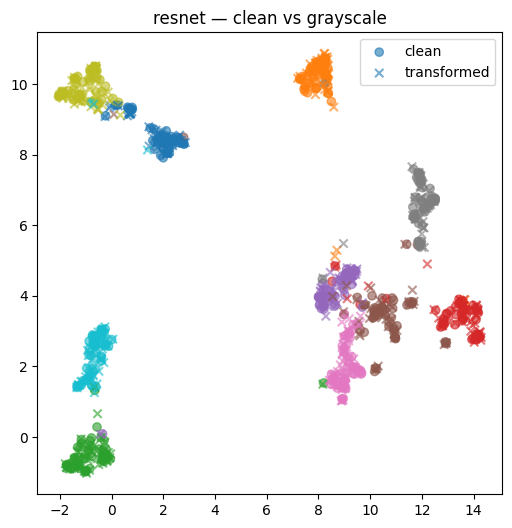

In [31]:
plot_clean_vs_transformed("resnet", "grayscale", lambda x: apply_color_intervention(x, "grayscale"), eval_loader)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


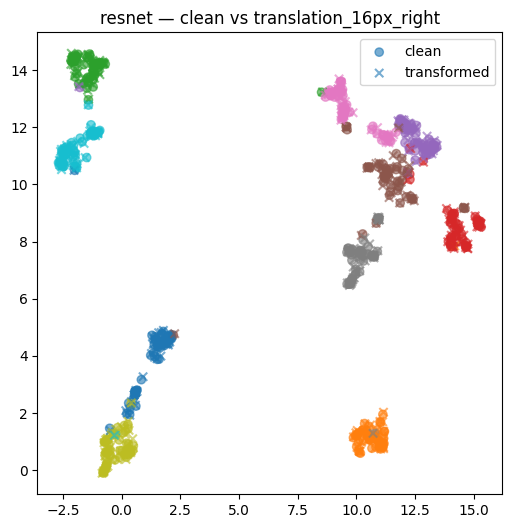

In [32]:
plot_clean_vs_transformed("resnet", "translation_16px_right", lambda x: translate_reflect(x, 16, 0), eval_loader)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


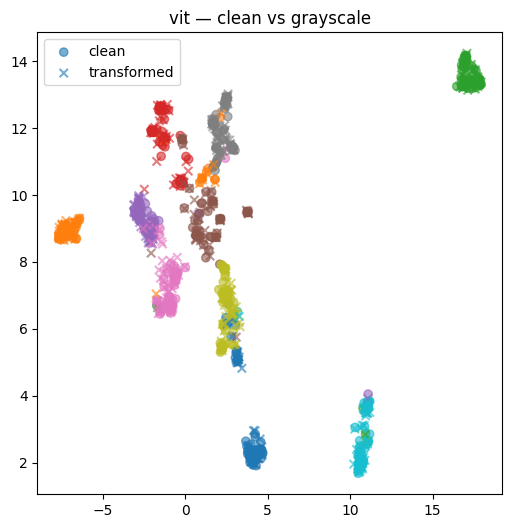

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


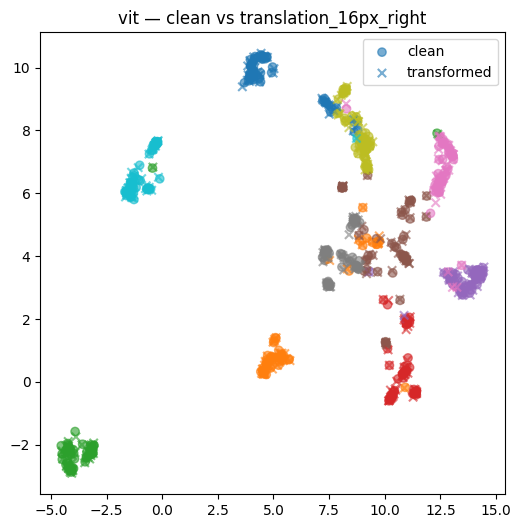

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


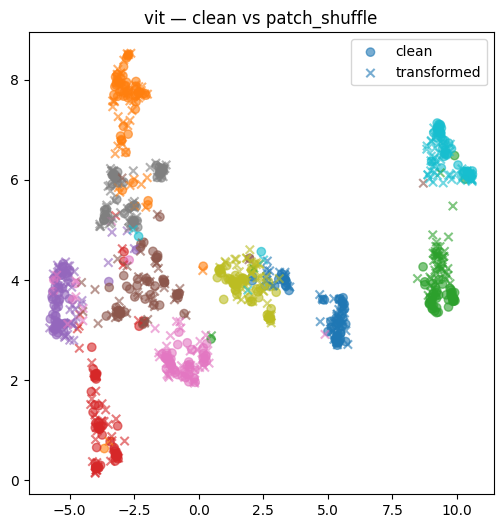

In [33]:
plot_clean_vs_transformed("vit", "grayscale", lambda x: apply_color_intervention(x, "grayscale"), eval_loader)
plot_clean_vs_transformed("vit", "translation_16px_right", lambda x: translate_reflect(x, 16, 0), eval_loader)
plot_clean_vs_transformed("vit", "patch_shuffle", patch_shuffle, eval_loader)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


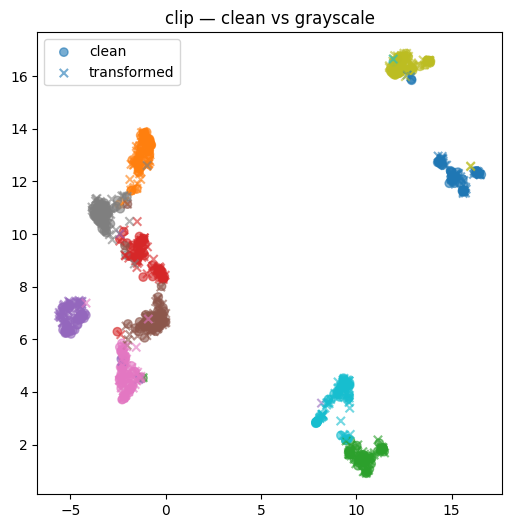

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


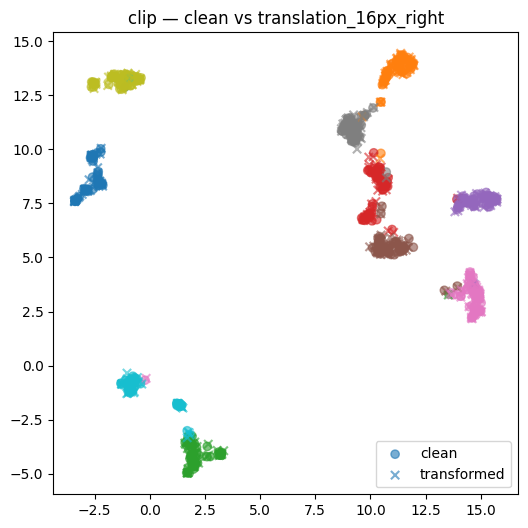

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


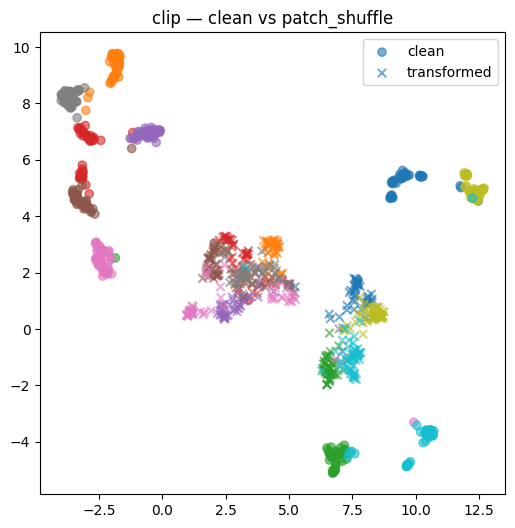

In [34]:
plot_clean_vs_transformed("clip", "grayscale", lambda x: apply_color_intervention(x, "grayscale"), eval_loader)
plot_clean_vs_transformed("clip", "translation_16px_right", lambda x: translate_reflect(x, 16, 0), eval_loader)
plot_clean_vs_transformed("clip", "patch_shuffle", patch_shuffle, eval_loader)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


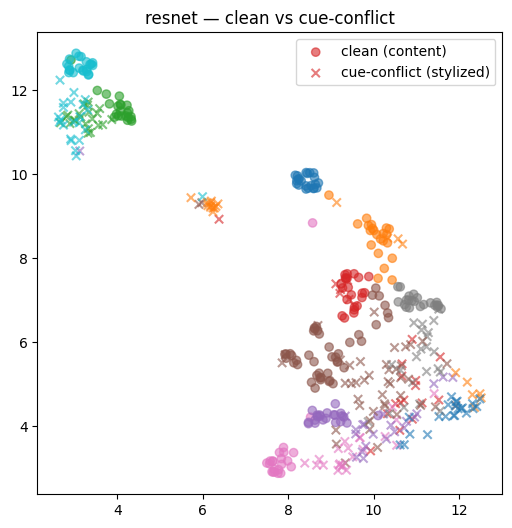

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


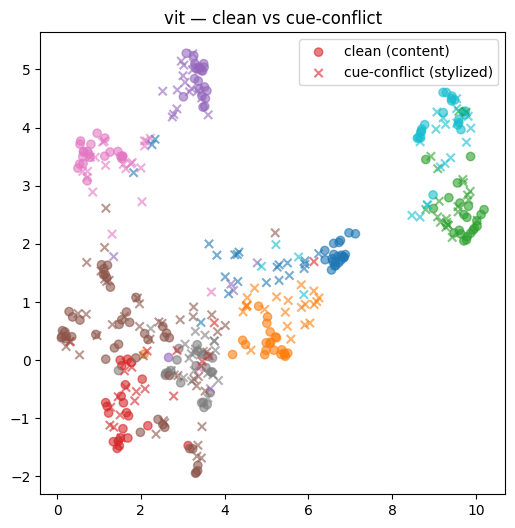

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


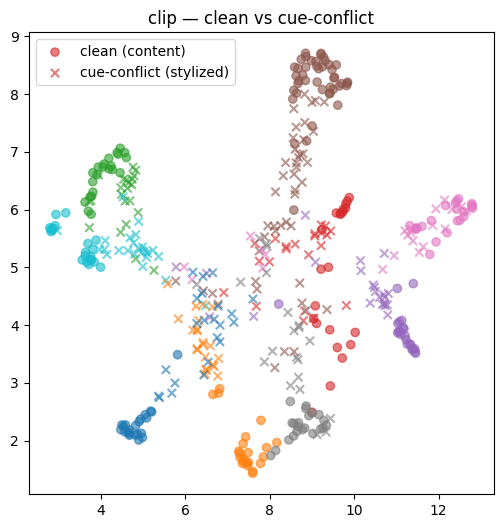

In [35]:
def plot_clean_vs_cue_conflict(model_name, manifest_records):
    stylized_imgs = torch.stack([base_transform(Image.open(r["path"]).convert("RGB")) for r in manifest_records])
    content_imgs = torch.stack([base_transform(Image.open(r["content_path"]).convert("RGB")) for r in manifest_records])
    labels = np.array([r["shape_label"] for r in manifest_records])

    with torch.no_grad():
        clean_f = extract_features(model_name, content_imgs).cpu().numpy()
        trans_f = extract_features(model_name, stylized_imgs).cpu().numpy()

    combined = np.concatenate([clean_f, trans_f], axis=0)
    proj = project_2d(combined, method="umap")
    n = len(clean_f)
    proj_clean, proj_trans = proj[:n], proj[n:]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(proj_clean[:,0], proj_clean[:,1], c=labels, cmap="tab10", marker="o", alpha=0.6, label="clean (content)")
    ax.scatter(proj_trans[:,0], proj_trans[:,1], c=labels, cmap="tab10", marker="x", alpha=0.6, label="cue-conflict (stylized)")
    ax.set_title(f"{model_name} — clean vs cue-conflict")
    ax.legend()
    plt.savefig(os.path.join(RESULTS_DIR, f"tsne_{model_name}_cue_conflict.png"), dpi=150, bbox_inches="tight")
    plt.show()

plot_clean_vs_cue_conflict("resnet", manifest)
plot_clean_vs_cue_conflict("vit", manifest)
plot_clean_vs_cue_conflict("clip", manifest)
